In [289]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylandau
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid

In [290]:
ALLPIX_FILE   = "main-input/allpix150V.csv"
GARFIELD_FILE = "main-input/garfield150V.csv"
SILVACO_FILE  = "main-input/silvaco150V.csv"

GARFIELD_CURVE = "i_gainON"
SILVACO_WIDTH_UM = 1.0

In [306]:
def load_allpix(path, col):
    allpix = np.genfromtxt(path, delimiter=",", names=True)
    (allpix.dtype.names)
    print(allpix.dtype.names)
    return allpix["t_ns"], allpix[col] # already ns / uA
    # t = allpix["t_ns"]
    # i = allpix[col] * 1e1
    # return t, i
 
def load_garfield(path, col):
    garfield = np.genfromtxt(path, delimiter=",", names=True)
    (garfield.dtype.names)
    print(garfield.dtype.names)
    return garfield["t_ns"], garfield[col] # fC/ns == uA
 
def load_silvaco(path, width_um):
    silvaco = np.genfromtxt(path, delimiter=",", names=True)
    print(silvaco.dtype.names)
    t_ns = silvaco["Transient_time"] * 1e9 # s -> ns
    i_uA = silvaco["Substrate_Current"] * -1e6 * width_um   # A/um -> uA
    fired = np.abs(i_uA) > 10 * np.abs(i_uA[0])
    baseline = i_uA[~fired].mean() if (~fired).any() else 0.0
    return t_ns, -(i_uA - baseline)
 
curves = {}
t, i = load_allpix(ALLPIX_FILE, "both_raw_uA")
curves["Allpix (pad, low-pass)"] = (t, i, "tab:green")
t, i = load_garfield(GARFIELD_FILE, GARFIELD_CURVE)
curves[f"Garfield++ ({GARFIELD_CURVE})"] = (t, i, "tab:red")
t, i = load_silvaco(SILVACO_FILE, SILVACO_WIDTH_UM)
curves["Silvaco (anode, sign-flipped)"] = (t, i, "tab:blue")
 
# collected charge: uA x ns = fC, directly comparable across simulators
_trap = getattr(np, "trapezoid", None) or np.trapz
print(f"{'curve':35s} {'peak [uA]':>12s} {'charge [fC]':>12s}")
for name, (t, i, c) in curves.items():
    print(f"{name:35s} {i[np.argmax(np.abs(i))]:12.3f} "
          f"{_trap(i, t):12.3f}")

('t_ns', 'left_raw_uA', 'left_fullBW_uA', 'left_reducedBW_uA', 'right_raw_uA', 'right_fullBW_uA', 'right_reducedBW_uA', 'both_raw_uA', 'both_fullBW_uA', 'both_reducedBW_uA')
('bin', 't_ns', 'i_gainON', 'i_gainOFF')
('Transient_time', 'Anode_Voltage', 'Anode_Int_Voltage', 'Anode_Current', 'Cathode_Voltage', 'Cathode_Int_Voltage', 'Cathode_Current', 'Substrate_Voltage', 'Substrate_Int_Voltage', 'Substrate_Current', 'SEU_Track_Charge', 'SEU_Track_Cumulative_Charge', 'SEU_Track_Generation_Rate')
curve                                  peak [uA]  charge [fC]
Allpix (pad, low-pass)                    -5.444       -3.860
Garfield++ (i_gainON)                     -7.347       -6.716
Silvaco (anode, sign-flipped)             -4.754       -4.587


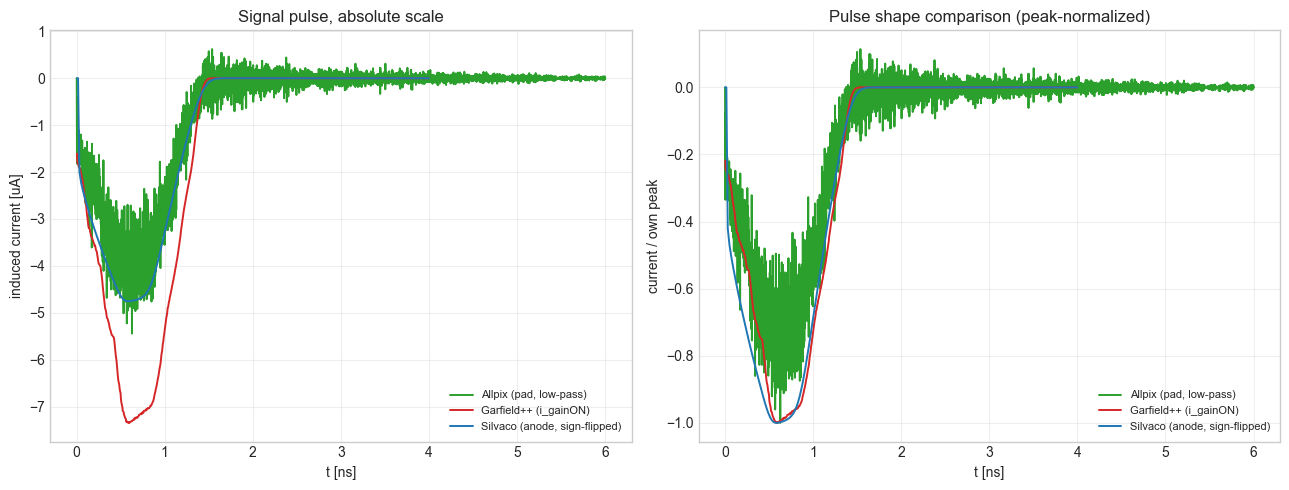

In [307]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
ax = axes[0]
for name, (t, i, c) in curves.items():
    ax.plot(t, i, color=c, lw=1.4, label=name)
ax.set_xlabel("t [ns]")
ax.set_ylabel("induced current [uA]")
ax.set_title("Signal pulse, absolute scale")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
for name, (t, i, c) in curves.items():
    peak = np.max(np.abs(i))
    ax.plot(t, i / peak if peak > 0 else i, color=c, lw=1.4, label=name)
ax.set_xlabel("t [ns]")
ax.set_ylabel("current / own peak")
ax.set_title("Pulse shape comparison (peak-normalized)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.show()

In [293]:
df = pd.read_csv("main-input/wfield_full.csv")

x = np.sort(df["x_um"].unique())
y = np.sort(df["y_um"].unique())
X, Y = np.meshgrid(x, y)

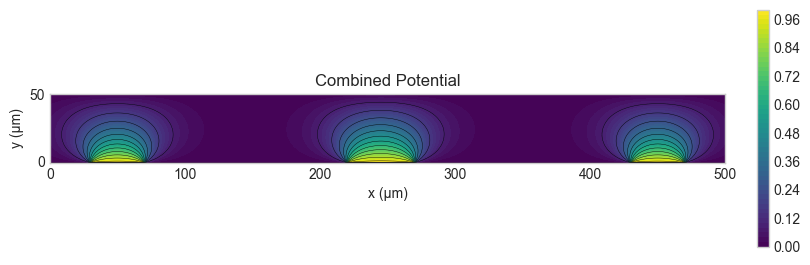

In [294]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

cf = ax.contourf(X, Y, Z, levels=50, cmap="viridis")
ax.contour(X, Y, Z, levels=15, colors="k", linewidths=0.3)

ax.set_title("Combined Potential")
ax.set_xlabel("x (μm)")
ax.set_ylabel("y (μm)")
ax.set_aspect("equal")

plt.colorbar(cf, ax=ax, shrink=0.4, pad=0.03)
plt.show()

In [295]:
ix = np.argmin(np.abs(x - 0))
dphidy, dphidx = np.gradient(Z, y, x)
Ex = -dphidx
Ey = -dphidy

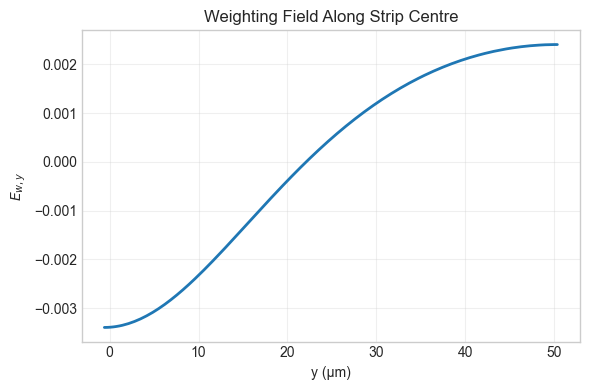

In [296]:
plt.figure(figsize=(6,4))

plt.plot(
    y,
    Ey[:,ix],
    lw=2
)

plt.xlabel("y (μm)")
plt.ylabel(r"$E_{w,y}$")
plt.title("Weighting Field Along Strip Centre")

plt.grid(alpha=0.3)

plt.tight_layout()

In [297]:
GARFIELD_OVERLAY = "main-input/Garfield1000MIPs150V.csv"
ALLPIX_OVERLAY = "main-input/Allpix1000MIPs150V.csv"  
SILVACO_FILE = "main-input/silvaco150V.csv"

In [311]:
def load_overlay(path):
    with open(path) as f:
        rows = [line.split(",") for line in f.read().splitlines() if line.strip()]
    
    header = rows[0]
    has_pairs = len(rows) > 1 and rows[1][0] == "nPairs"
    start = 2 if has_pairs else 1
    pairs = np.array(rows[1][1:], dtype=float) if has_pairs else None
    
    data = np.array([r for r in rows[start:] if len(r) == len(header)], dtype=float)
    t_idx = header.index("time_ns")
    data = data[np.isfinite(data[:, t_idx])]
    
    trk_cols = [i for i, c in enumerate(header) if c.startswith("trk")]
    return data[:, t_idx], data[:, trk_cols], pairs

def load_silvaco(path, width_um):
    d = np.genfromtxt(path, delimiter=",", names=True)
    t, i = d["Transient_time"] * 1e9, d["Substrate_Current"] * -1e6 * width_um
    baseline = np.mean(i[np.abs(i) <= 10 * np.abs(i[0])])
    return t, -(i - baseline)

def fit_langau(charge, bins=80):
    if len(charge) < 20: 
        return None
        
    counts, edges = np.histogram(charge, bins=bins, density=True)
    centers = (edges[1:] + edges[:-1]) / 2
    
    func = lambda x, mpv, eta, sigma, A: pylandau.langau(x, mpv, eta, sigma, A)
    p0 = [centers[np.argmax(counts)], np.std(charge) * 0.5, np.std(charge) * 0.3, counts.max()]
    
    popt, pcov = curve_fit(func, centers, counts, p0=p0, maxfev=20000, bounds=(0, np.inf))
    
    return {"mpv": popt[0], "mpv_err": np.sqrt(pcov[0, 0]), "width": popt[1],
            "curve": lambda x: func(x, *popt), "method": "Landau (x) Gauss"}

t_g, sig_g, pairs_g = load_overlay(GARFIELD_OVERLAY)
df_q = pd.read_csv(ALLPIX_OVERLAY)
t_q, sig_q = df_q["time_ns"].values, df_q.drop(columns=["time_ns"]).values

t_s, i_s = load_silvaco(SILVACO_FILE, 1.0)

print(f"Garfield: {sig_g.shape[1]} tracks, t in [{t_g.min():.3g}, {t_g.max():.3g}] ns")
print(f"Allpix:   {sig_q.shape[1]} events, t in [{t_q.min():.3g}, {t_q.max():.3g}] ns")
print(f"Silvaco:  1 event, t in [{t_s.min():.3g}, {t_s.max():.3g}] ns")

Garfield: 200 tracks, t in [0.0025, 4] ns
Allpix:   1000 events, t in [0, 6] ns
Silvaco:  1 event, t in [0.001, 4] ns


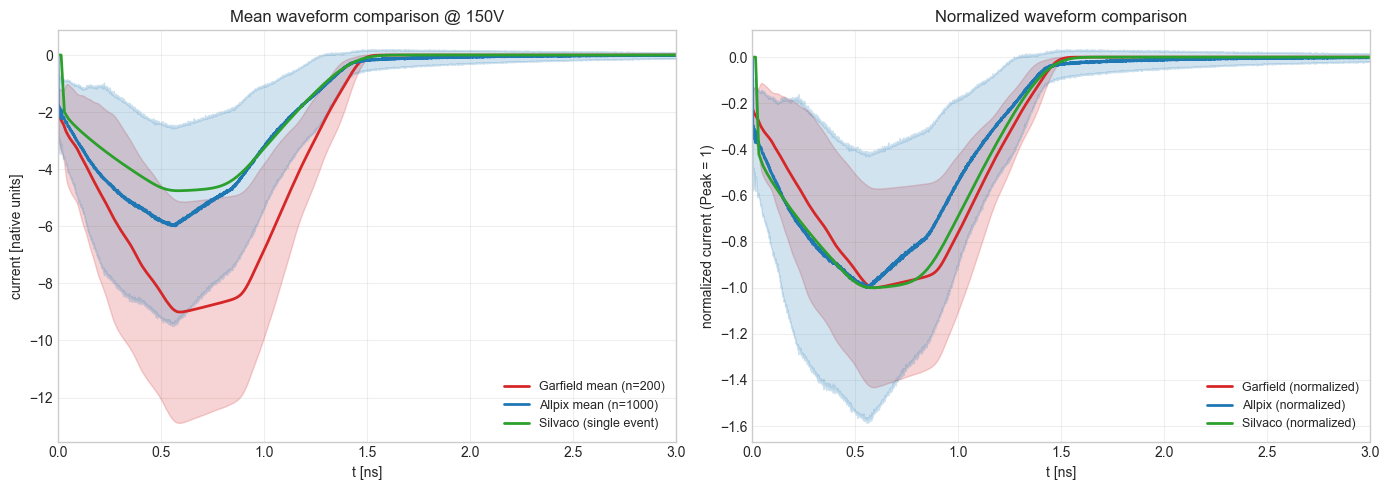

peak of mean -- Garfield: -9.004   Allpix: -5.987   Silvaco: -4.754


In [313]:
mean_g = sig_g.mean(axis=1)
mean_q = sig_q.mean(axis=1)
std_g = sig_g.std(axis=1)
std_q = sig_q.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t_g, mean_g, color="tab:red", lw=2,
       label=f"Garfield mean (n={sig_g.shape[1]})")
axes[0].fill_between(t_g, mean_g - std_g, mean_g + std_g, color="tab:red", alpha=0.2)
axes[0].plot(t_q, mean_q, color="tab:blue", lw=2,
       label=f"Allpix mean (n={sig_q.shape[1]})")
axes[0].fill_between(t_q, mean_q - std_q, mean_q + std_q, color="tab:blue", alpha=0.2)

if t_s is not None:
    axes[0].plot(t_s, i_s, color="tab:green", lw=2, label="Silvaco (single event)")

axes[0].set_xlabel("t [ns]")
axes[0].set_ylabel("current [native units]")
axes[0].set_title("Mean waveform comparison @ 150V")
axes[0].set_xlim(0, 3)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

max_g = np.max(np.abs(mean_g))
max_q = np.max(np.abs(mean_q))

norm_g = mean_g / max_g
norm_q = mean_q / max_q

norm_std_g = std_g / max_g
norm_std_q = std_q / max_q

axes[1].plot(t_g, norm_g, color="tab:red", lw=2, label="Garfield (normalized)")
# Add Garfield normalized +- 1 sigma band
axes[1].fill_between(t_g, norm_g - norm_std_g, norm_g + norm_std_g, color="tab:red", alpha=0.2)

axes[1].plot(t_q, norm_q, color="tab:blue", lw=2, label="Allpix (normalized)")
# Add Allpix normalized +- 1 sigma band
axes[1].fill_between(t_q, norm_q - norm_std_q, norm_q + norm_std_q, color="tab:blue", alpha=0.2)

if t_s is not None:
    norm_s = i_s / np.max(np.abs(i_s))
    axes[1].plot(t_s, norm_s, color="tab:green", lw=2, label="Silvaco (normalized)")

axes[1].set_xlabel("t [ns]")
axes[1].set_ylabel("normalized current (Peak = 1)")
axes[1].set_title("Normalized waveform comparison")
axes[1].set_xlim(0, 3)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"peak of mean -- Garfield: {mean_g[np.argmax(np.abs(mean_g))]:.3f}"
      f"   Allpix: {mean_q[np.argmax(np.abs(mean_q))]:.3f}"
      + (f"   Silvaco: {i_s[np.argmax(np.abs(i_s))]:.3f}" if t_s is not None else ""))

In [309]:
GARFIELD_180V = "main-input/Garfield1000MIPs180V.csv"
ALLPIX_180V = "main-input/Allpix1000MIPs180V.csv"
SILVACO_180V = "main-input/lgad_deepjte_180V-x80_trans1.csv"

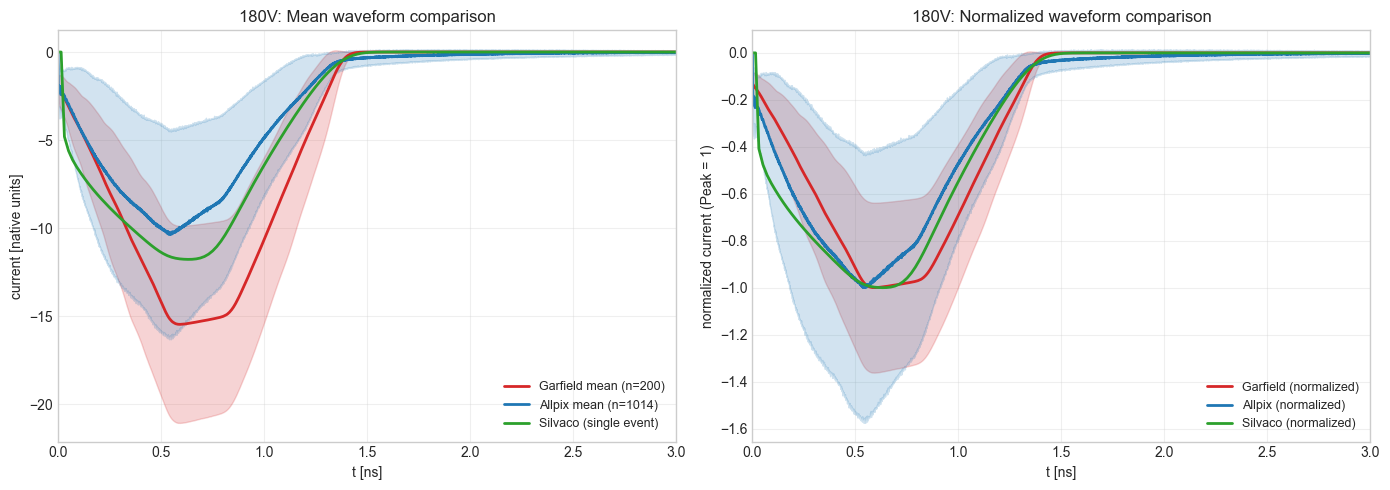

180V peak of mean -- Garfield: -15.467   Allpix: -10.355   Silvaco: -11.776


In [312]:
t_g_180, sig_g_180, pairs_g_180 = load_overlay(GARFIELD_180V)
df_q_180 = pd.read_csv(ALLPIX_180V)
t_q_180, sig_q_180 = df_q_180["time_ns"].values, df_q_180.drop(columns=["time_ns"]).values
t_s_180, i_s_180 = load_silvaco(SILVACO_180V, 1.0)

mean_g_180 = sig_g_180.mean(axis=1)
mean_q_180 = sig_q_180.mean(axis=1)
std_g_180 = sig_g_180.std(axis=1)
std_q_180 = sig_q_180.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t_g_180, mean_g_180, color="tab:red", lw=2,
       label=f"Garfield mean (n={sig_g_180.shape[1]})")
axes[0].fill_between(t_g_180, mean_g_180 - std_g_180, mean_g_180 + std_g_180, color="tab:red", alpha=0.2)

axes[0].plot(t_q_180, mean_q_180, color="tab:blue", lw=2,
       label=f"Allpix mean (n={sig_q_180.shape[1]})")
axes[0].fill_between(t_q_180, mean_q_180 - std_q_180, mean_q_180 + std_q_180, color="tab:blue", alpha=0.2)

if t_s_180 is not None:
    axes[0].plot(t_s_180, i_s_180, color="tab:green", lw=2, label="Silvaco (single event)")

axes[0].set_xlabel("t [ns]")
axes[0].set_ylabel("current [native units]")
axes[0].set_title("180V: Mean waveform comparison")
axes[0].set_xlim(0, 3)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

max_g_180 = np.max(np.abs(mean_g_180))
max_q_180 = np.max(np.abs(mean_q_180))

norm_g_180 = mean_g_180 / max_g_180
norm_q_180 = mean_q_180 / max_q_180

norm_std_g_180 = std_g_180 / max_g_180
norm_std_q_180 = std_q_180 / max_q_180

axes[1].plot(t_g_180, norm_g_180, color="tab:red", lw=2, label="Garfield (normalized)")
axes[1].fill_between(t_g_180, norm_g_180 - norm_std_g_180, norm_g_180 + norm_std_g_180, color="tab:red", alpha=0.2)

axes[1].plot(t_q_180, norm_q_180, color="tab:blue", lw=2, label="Allpix (normalized)")
axes[1].fill_between(t_q_180, norm_q_180 - norm_std_q_180, norm_q_180 + norm_std_q_180, color="tab:blue", alpha=0.2)

if t_s_180 is not None:
    norm_s_180 = i_s_180 / np.max(np.abs(i_s_180))
    axes[1].plot(t_s_180, norm_s_180, color="tab:green", lw=2, label="Silvaco (normalized)")

axes[1].set_xlabel("t [ns]")
axes[1].set_ylabel("normalized current (Peak = 1)")
axes[1].set_title("180V: Normalized waveform comparison")
axes[1].set_xlim(0, 3)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"180V peak of mean -- Garfield: {mean_g_180[np.argmax(np.abs(mean_g_180))]:.3f}"
      f"   Allpix: {mean_q_180[np.argmax(np.abs(mean_q_180))]:.3f}"
      + (f"   Silvaco: {i_s_180[np.argmax(np.abs(i_s_180))]:.3f}" if t_s_180 is not None else ""))

In [ ]:
FIELD_DATA_CSV = "main-input/efield_full.csv"

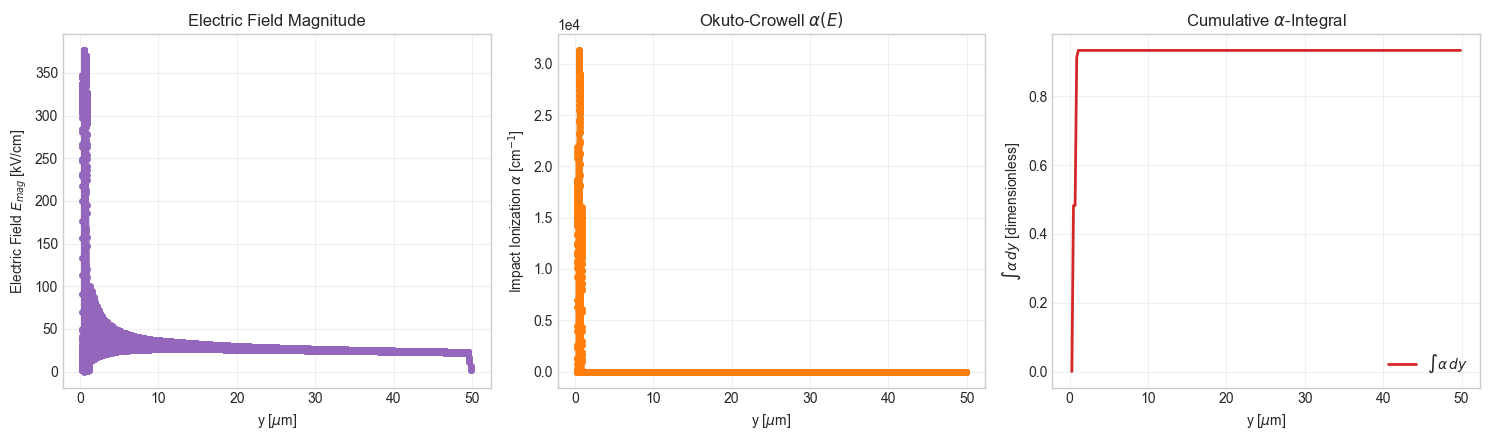

Total alpha-integral: 0.93317
Estimated Multiplication Gain (e^int): 2.54256


In [ ]:
a_300 = 0.426      # V^-1
b_300 = 4.81e5     # V/cm

df_field = pd.read_csv(FIELD_DATA_CSV)


df_field = df_field.sort_values(by="y_um").reset_index(drop=True)

y_um = df_field["y_um"].values
Emag = df_field["Emag_Vcm"].values
y_cm = y_um * 1e-4

alpha = np.where(Emag > 0, a_300 * Emag * np.exp(-(b_300 / Emag)**2), 0.0)
alpha_integral = cumulative_trapezoid(alpha, y_cm, initial=0)
gain = np.exp(alpha_integral)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(y_um, Emag / 1000, color="tab:purple", lw=2, marker="o", markersize=4)
axes[0].set_xlabel(r"y [$\mu$m]")
axes[0].set_ylabel("Electric Field $E_{mag}$ [kV/cm]")
axes[0].set_title("Electric Field Magnitude")
axes[0].grid(alpha=0.3)

axes[1].plot(y_um, alpha, color="tab:orange", lw=2, marker="o", markersize=4)
axes[1].set_xlabel(r"y [$\mu$m]")
axes[1].set_ylabel("Impact Ionization $\\alpha$ [cm$^{-1}$]")
axes[1].set_title("Okuto-Crowell $\\alpha(E)$")
axes[1].grid(alpha=0.3)
axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

axes[2].plot(y_um, alpha_integral, color="tab:red", lw=2, label="$\\int \\alpha \\, dy$")
axes[2].set_xlabel(r"y [$\mu$m]")
axes[2].set_ylabel("$\\int \\alpha \\, dy$ [dimensionless]")
axes[2].set_title("Cumulative $\\alpha$-Integral")
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total alpha-integral: {alpha_integral[-1]:.5f}")
print(f"Estimated Multiplication Gain (e^int): {gain[-1]:.5f}")

In [ ]:
a_e = 0.426      # V^-1
b_e = 4.81e5     # V/cm
a_h = 0.225      # V^-1
b_h = 6.51e5     # V/cm

alpha = np.where(Emag > 0, a_e * Emag * np.exp(-(b_e / Emag)**2), 0.0)
beta  = np.where(Emag > 0, a_h * Emag * np.exp(-(b_h / Emag)**2), 0.0)

delta = alpha - beta

inner_integral = cumulative_trapezoid(delta, y_cm, initial=0)

phi = np.exp(-inner_integral)
integrand = alpha * phi
outer_integral = cumulative_trapezoid(integrand, y_cm, initial=0)

M_e = 1.0 / (1.0 - outer_integral[-1])
print(f"Electron-initiated Gain (McIntyre): {M_e:.5f}")

Electron-initiated Gain (McIntyre): 2.71124


In [ ]:
GARFIELD_FILE_ng = "main-input/Garfield1000MIPs180V_ng.csv"
SILVACO_FILE_ng = "main-input/silvaco180Vng.csv"

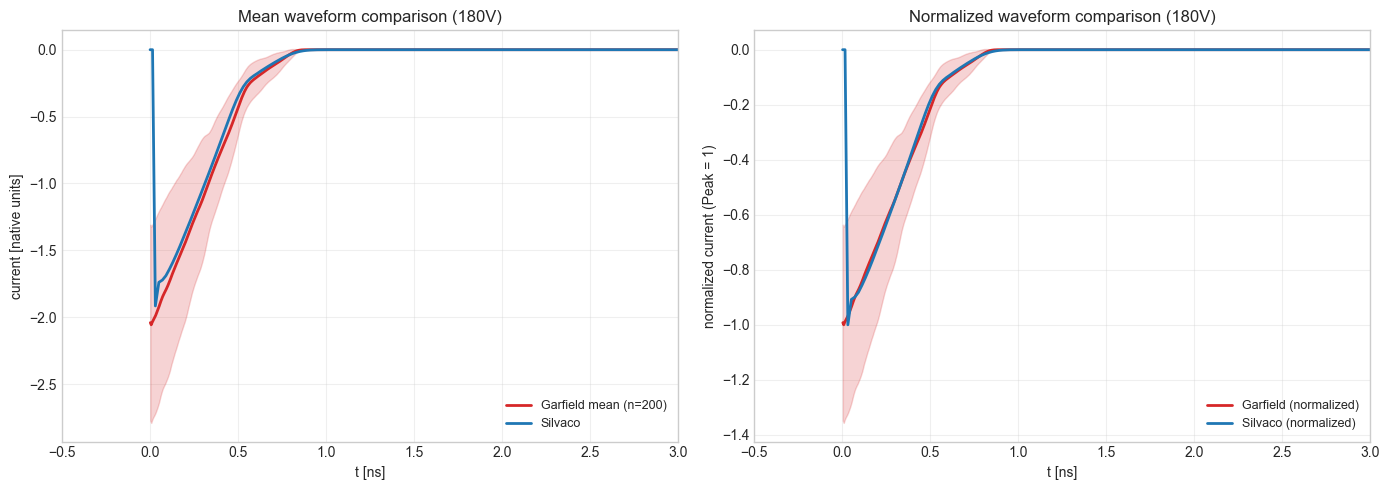

Garfield: 200 tracks, t in [0.0025, 4] ns
peak of mean -- Garfield: -2.057   Silvaco: -1.916


In [ ]:
def load_overlay(path):
    with open(path) as f:
        lines = f.read().splitlines()
    header = lines[0].split(",")
    ncols = len(header)
    t_idx = header.index("time_ns")
    trk_idx = [i for i, c in enumerate(header) if c.startswith("trk")]
    start = 1
    pairs = None
    if len(lines) > 1 and lines[1].startswith("nPairs"):
        pairs = np.array([float(v) for v in lines[1].split(",")[1:]])
        start = 2
    t_list, sig_rows = [], []
    for ln in lines[start:]:
        if not ln.strip():
            continue
        parts = ln.split(",")
        if len(parts) != ncols:
            continue
        vals = [float(x) for x in parts]
        if not np.isfinite(vals[t_idx]):
            continue
        t_list.append(vals[t_idx])
        sig_rows.append([vals[i] for i in trk_idx])
    return np.array(t_list), np.array(sig_rows), pairs

def load_silvaco(path, width_um):
    silvaco = np.genfromtxt(path, delimiter=",", names=True)
    t_ns = silvaco["Transient_time"] * 1e9
    i_uA = silvaco["Anode_Current"] * 1e6 * width_um
    fired = np.abs(i_uA) > 10 * np.abs(i_uA[0])
    baseline = i_uA[~fired].mean() if (~fired).any() else 0.0
    return t_ns, -(i_uA - baseline)

t_g, sig_g, pairs_g = load_overlay(GARFIELD_FILE_ng)
t_s, i_s = load_silvaco(SILVACO_FILE_ng, 1.0)

mean_g = sig_g.mean(axis=1)
std_g = sig_g.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t_g, mean_g, color="tab:red", lw=2,
       label=f"Garfield mean (n={sig_g.shape[1]})")
axes[0].fill_between(t_g, mean_g - std_g, mean_g + std_g, color="tab:red", alpha=0.2)

axes[0].plot(t_s, i_s, color="tab:blue", lw=2, label="Silvaco")

axes[0].set_xlabel("t [ns]")
axes[0].set_ylabel("current [native units]")
axes[0].set_title("Mean waveform comparison (180V)")
axes[0].set_xlim(-0.5, 3) 
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

max_g = np.max(np.abs(mean_g))
norm_g = mean_g / max_g
norm_std_g = std_g / max_g

max_s = np.max(np.abs(i_s))
norm_s = i_s / max_s

axes[1].plot(t_g, norm_g, color="tab:red", lw=2, label="Garfield (normalized)")
axes[1].fill_between(t_g, norm_g - norm_std_g, norm_g + norm_std_g, color="tab:red", alpha=0.2)

axes[1].plot(t_s, norm_s, color="tab:blue", lw=2, label="Silvaco (normalized)")

axes[1].set_xlabel("t [ns]")
axes[1].set_ylabel("normalized current (Peak = 1)")
axes[1].set_title("Normalized waveform comparison (180V)")
axes[1].set_xlim(-0.5, 3) 
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Garfield: {sig_g.shape[1]} tracks, t in [{t_g.min():.3g}, {t_g.max():.3g}] ns")
print(f"peak of mean -- Garfield: {mean_g[np.argmax(np.abs(mean_g))]:.3f}   Silvaco: {i_s[np.argmax(np.abs(i_s))]:.3f}")

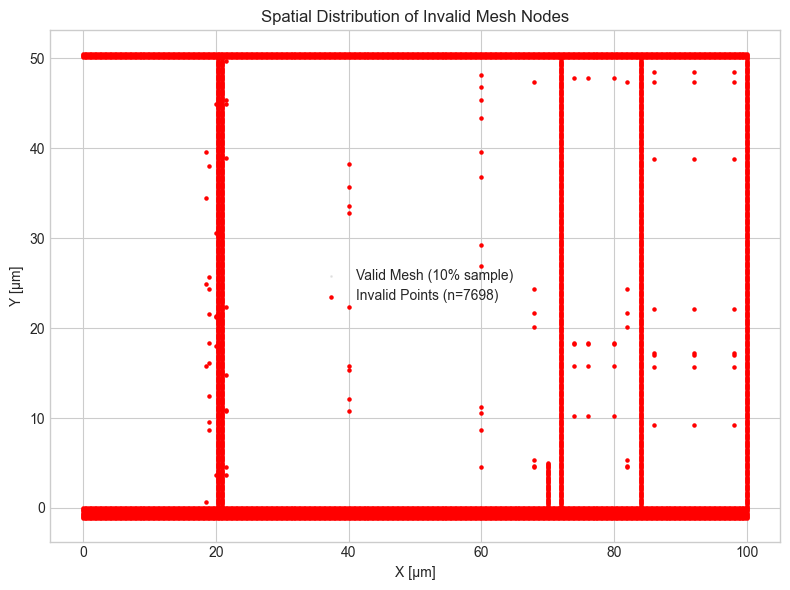

In [ ]:
df = pd.read_csv("main-input/validity_map.csv")

valid_pts = df[df["status"] == 0]
invalid_pts = df[df["status"] != 0]

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(valid_pts["x_um"][::10], valid_pts["y_um"][::10], 
           color="lightgray", s=1, alpha=0.5, label="Valid Mesh (10% sample)")

ax.scatter(invalid_pts["x_um"], invalid_pts["y_um"], 
           color="red", s=5, label=f"Invalid Points (n={len(invalid_pts)})")

ax.set_xlabel("X [µm]")
ax.set_ylabel("Y [µm]")
ax.set_title("Spatial Distribution of Invalid Mesh Nodes")
ax.legend()
plt.tight_layout()
plt.show()

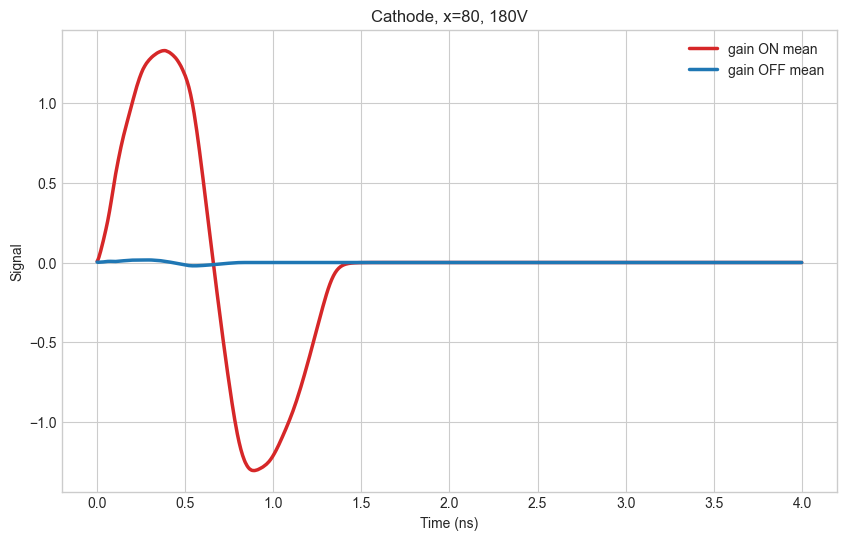

In [ ]:
on = pd.read_csv("main-input/signal_overlay_cathode180V.csv", skiprows=[1])
off = pd.read_csv("main-input/signal_overlay_noGain_cathode180V.csv", skiprows=[1])

t = on["time_ns"].values
son = on.drop(columns=["time_ns"]).values
soff = off.drop(columns=["time_ns"]).values

plt.figure(figsize=(10,6))
plt.plot(t, son.mean(axis=1), color="tab:red", lw=2.5, label="gain ON mean")
plt.plot(t, soff.mean(axis=1), color="tab:blue", lw=2.5, label="gain OFF mean")
plt.xlabel("Time (ns)")
plt.ylabel("Signal")
plt.title("Cathode, x=80, 180V")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
on_a = pd.read_csv("main-input/signal_overlay_anode180V.csv", skiprows=[1])
son_a = on_a.drop(columns=["time_ns"]).values
print("cathode peak:", son.min(axis=0).mean())
print("anode peak:  ", son_a.min(axis=0).mean())

cathode peak: -1.4643771950000002
anode peak:   -31.935967


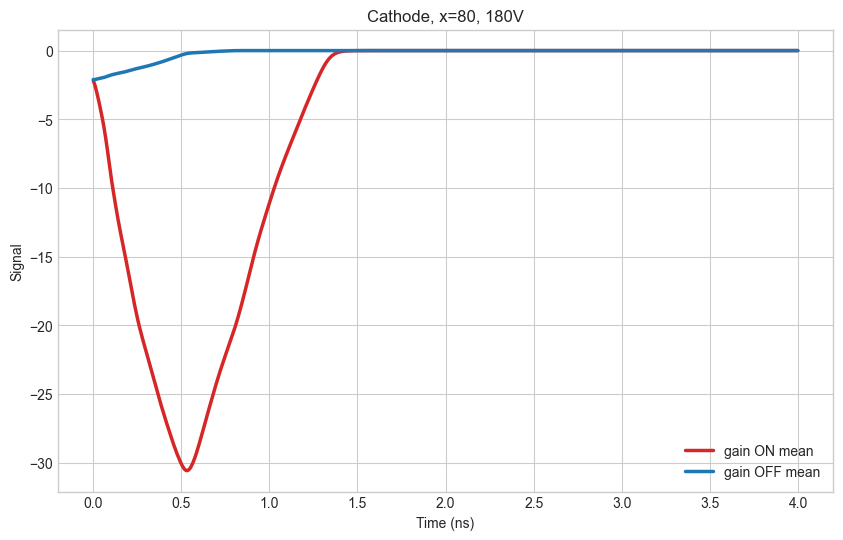

In [ ]:
a_on = pd.read_csv("main-input/signal_overlay_anode180V.csv", skiprows=[1])
a_off = pd.read_csv("main-input/signal_overlay_noGain_anode180V.csv", skiprows=[1])

t_ns = a_on["time_ns"].values
a_son = a_on.drop(columns=["time_ns"]).values
a_soff = a_off.drop(columns=["time_ns"]).values

plt.figure(figsize=(10,6))
plt.plot(t_ns, a_son.mean(axis=1), color="tab:red", lw=2.5, label="gain ON mean")
plt.plot(t_ns, a_soff.mean(axis=1), color="tab:blue", lw=2.5, label="gain OFF mean")
plt.xlabel("Time (ns)")
plt.ylabel("Signal")
plt.title("Cathode, x=80, 180V")
plt.legend()
plt.grid(True)
plt.show()

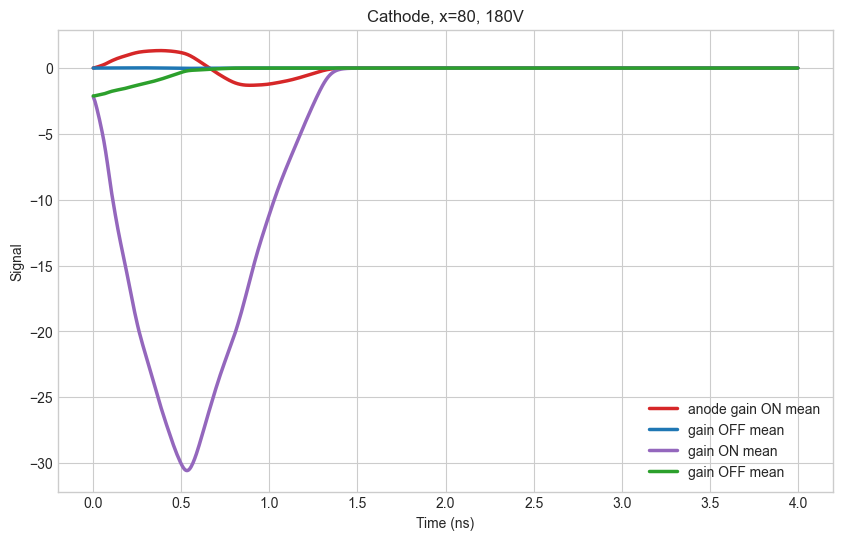

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(t, son.mean(axis=1), color="tab:red", lw=2.5, label="anode gain ON mean")
plt.plot(t, soff.mean(axis=1), color="tab:blue", lw=2.5, label="gain OFF mean")
plt.plot(t_ns, a_son.mean(axis=1), color="tab:purple", lw=2.5, label="gain ON mean")
plt.plot(t_ns, a_soff.mean(axis=1), color="tab:green", lw=2.5, label="gain OFF mean")
plt.xlabel("Time (ns)")
plt.ylabel("Signal")
plt.title("Cathode, x=80, 180V")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
CSV_FILENAME = "main-input/charge_sharing.csv"
df = pd.read_csv(CSV_FILENAME)

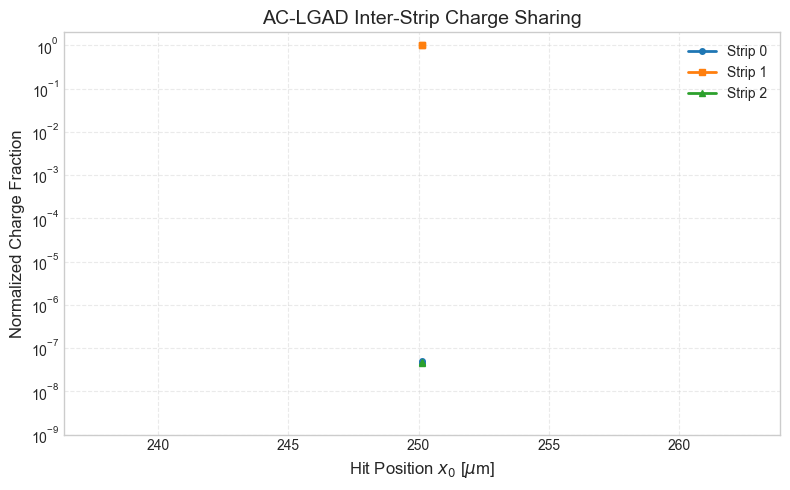

In [ ]:
df = df.sort_values(by="x0_um").reset_index(drop=True)

x0_um = df["x0_um"].values

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x0_um, df["strip0_frac"], color="tab:blue", lw=2, marker='o', markersize=4, label="Strip 0")
ax.plot(x0_um, df["strip1_frac"], color="tab:orange", lw=2, marker='s', markersize=4, label="Strip 1")
ax.plot(x0_um, df["strip2_frac"], color="tab:green", lw=2, marker='^', markersize=4, label="Strip 2")

ax.set_xlabel(r"Hit Position $x_0$ [$\mu$m]", fontsize=12)
ax.set_ylabel("Normalized Charge Fraction", fontsize=12)
ax.set_title("AC-LGAD Inter-Strip Charge Sharing", fontsize=14)

ax.set_yscale("log")
ax.set_ylim(1e-9, 2.0)

# Add a subtle grid for readability
ax.grid(alpha=0.4, linestyle='--')
ax.legend(fontsize=10, loc="best")

plt.tight_layout()
plt.show()

Calculating Peak MPVs...
Gain ON Peak MPV: 27.47835
Gain OFF Peak MPV: 1.89346


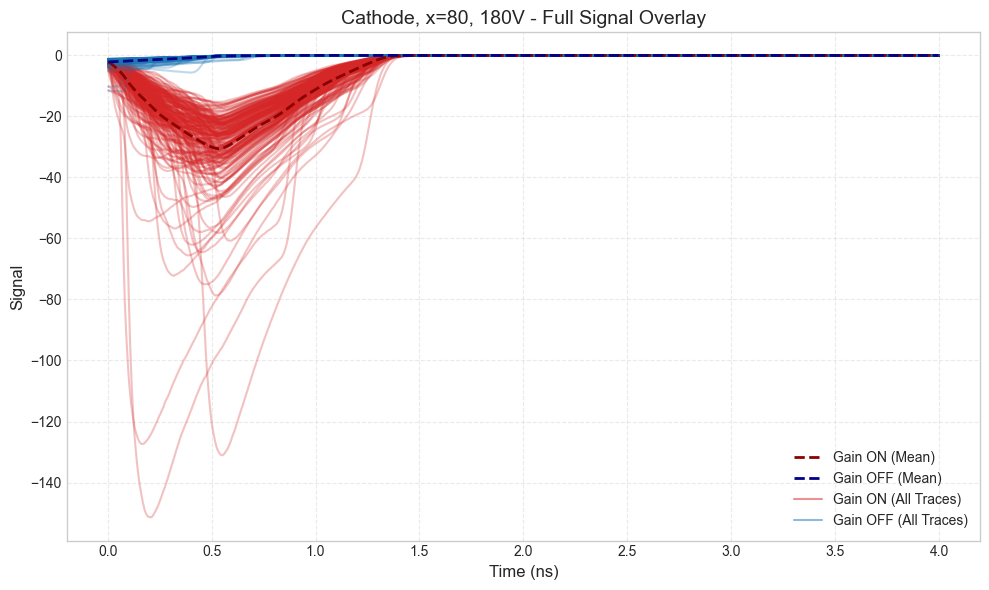

In [ ]:

a_on = pd.read_csv("main-input/signal_overlay_anode180V.csv", skiprows=[1])
a_off = pd.read_csv("main-input/signal_overlay_noGain_anode180V.csv", skiprows=[1])


t_ns = a_on["time_ns"].values
a_son = a_on.drop(columns=["time_ns"]).values
a_soff = a_off.drop(columns=["time_ns"]).values

def calculate_peak_mpv(signal_2d_array):

    peaks = np.max(np.abs(signal_2d_array), axis=0)
    
    if np.std(peaks) < 1e-12:
        return np.mean(peaks)
        kde = gaussian_kde(peaks)
        x_grid = np.linspace(peaks.min(), peaks.max(), 500)
        kde_vals = kde.evaluate(x_grid)
    return np.median(peaks)

print("Calculating Peak MPVs...")
mpv_on_val = calculate_peak_mpv(a_son)
mpv_off_val = calculate_peak_mpv(a_soff)

print(f"Gain ON Peak MPV: {mpv_on_val:.5f}")
print(f"Gain OFF Peak MPV: {mpv_off_val:.5f}")

plt.figure(figsize=(10,6))
plt.plot(t_ns, a_son, color="tab:red", alpha=0.15)
plt.plot(t_ns, a_soff, color="tab:blue", alpha=0.15)
plt.plot(t_ns, a_son, color="tab:red", alpha=0.15)
plt.plot(t_ns, a_soff, color="tab:blue", alpha=0.15)
plt.plot(t_ns, a_son.mean(axis=1), color="darkred", lw=2, linestyle="--", label="Gain ON (Mean)")
plt.plot(t_ns, a_soff.mean(axis=1), color="darkblue", lw=2, linestyle="--", label="Gain OFF (Mean)")
plt.plot([], [], color="tab:red", alpha=0.5, label="Gain ON (All Traces)")
plt.plot([], [], color="tab:blue", alpha=0.5, label="Gain OFF (All Traces)")

plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("Signal", fontsize=12)
plt.title("Cathode, x=80, 180V - Full Signal Overlay", fontsize=14)
plt.legend(fontsize=10, loc="best")
plt.grid(True, alpha=0.4, linestyle="--")

plt.tight_layout()
plt.show()

In [349]:
GARFIELD_180V_x80 = "main-input/garfield180V_x80.csv"
SILVACO_180V_x80 = "main-input/lgad_deepjte_180V-x80_trans1.csv"

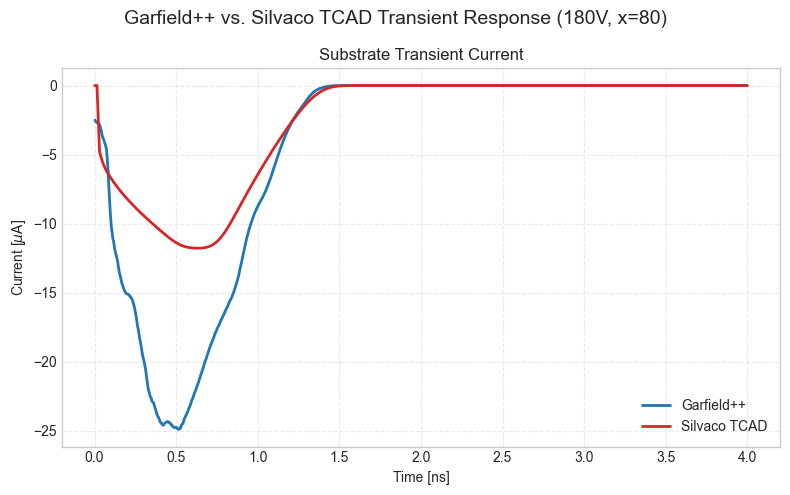

In [350]:

df_garfield = pd.read_csv(GARFIELD_180V_x80)
    
t_garf_ns = df_garfield["t_ns"].values
c_garf_substrate = df_garfield["cathode_ON"].values

df_silvaco = pd.read_csv(SILVACO_180V_x80)
t_silv_ns = df_silvaco["Transient time"].values * 1e9
c_silv_substrate = df_silvaco["Substrate Current"].values * 1e6

fig, ax = plt.subplots(figsize=(8, 5))

if len(t_garf_ns) > 0 and len(c_garf_substrate) > 0:
    ax.plot(t_garf_ns, c_garf_substrate, label="Garfield++", color="tab:blue", lw=2)
if len(t_silv_ns) > 0:
    ax.plot(t_silv_ns, c_silv_substrate, label="Silvaco TCAD", color="tab:red", lw=2)

ax.set_xlabel("Time [ns]")
ax.set_ylabel(r"Current [$\mu$A]")
ax.set_title("Substrate Transient Current")
ax.legend()
ax.grid(True, alpha=0.4, linestyle="--")

plt.suptitle("Garfield++ vs. Silvaco TCAD Transient Response (180V, x=80)", fontsize=14)
plt.tight_layout()
plt.show()